In [1]:
import os
import math
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import itertools
import glob

def make_combination(config_dict):
    keys, values = zip(*config_dict.items())
    return [dict(zip(keys, v)) for v in itertools.product(*values)]

In [2]:
UEA_MTSC30 = ['EthanolConcentration',
              'FaceDetection',
              'Handwriting',
              'Heartbeat',
              'JapaneseVowels',
              'PEMS-SF',
              'SelfRegulationSCP1',
              'SelfRegulationSCP2',
              'SpokenArabicDigits',
              'UWaveGestureLibrary',
              'ArticularyWordRecognition',
              'AtrialFibrillation',
              'BasicMotions',
              'CharacterTrajectories',
              'Cricket',
              'DuckDuckGeese',
              'EigenWorms',
              'Epilepsy',
              'ERing',
              'FingerMovements',
              'HandMovementDirection',
              'InsectWingbeat',
              'Libras',
              'LSST',
              'MotorImagery',
              'NATOPS',
              'PenDigits',
              'PhonemeSpectra',
              'RacketSports',
              'StandWalkJump']

In [3]:
from omegaconf import OmegaConf
data_info = OmegaConf.load(f"../data_classification.yaml")

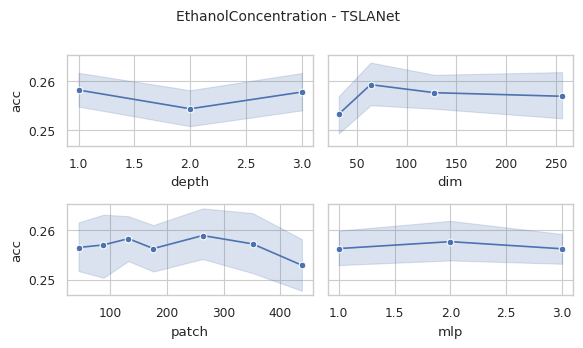

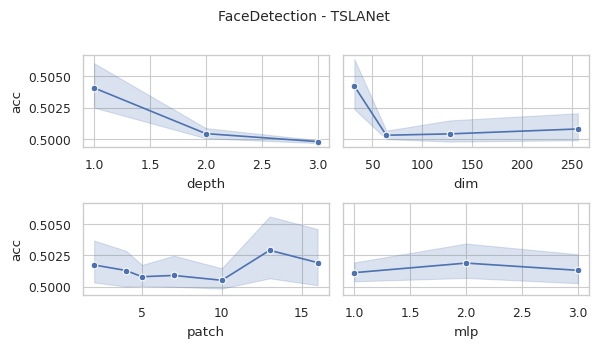

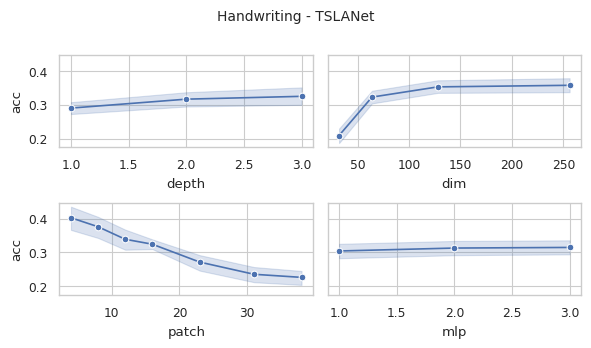

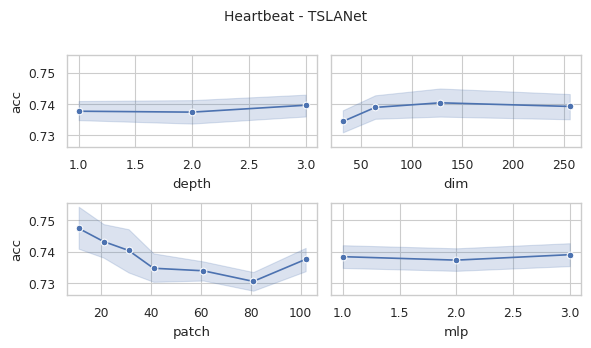

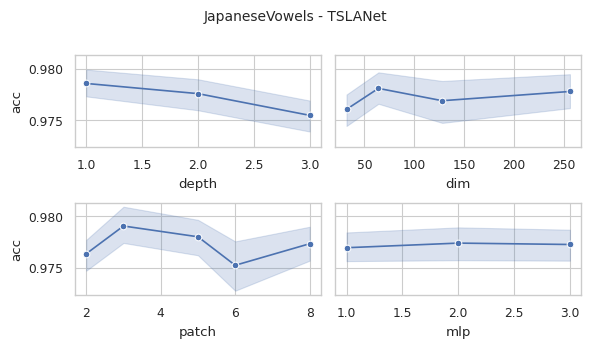

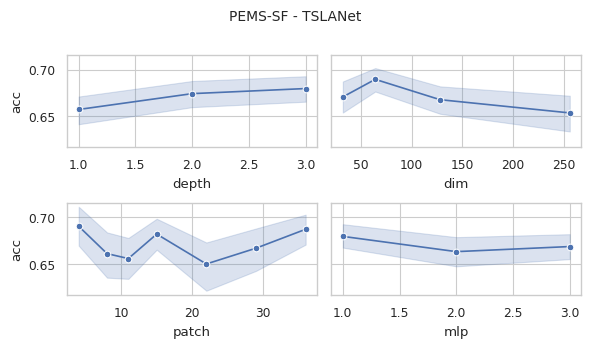

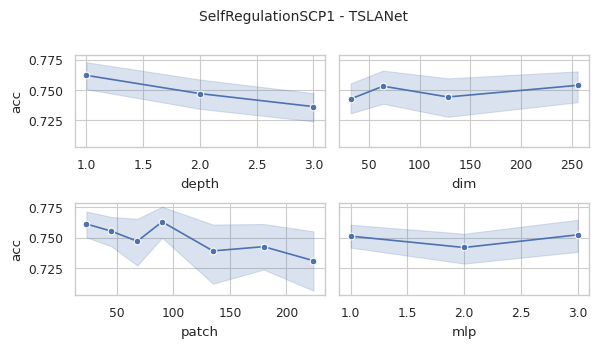

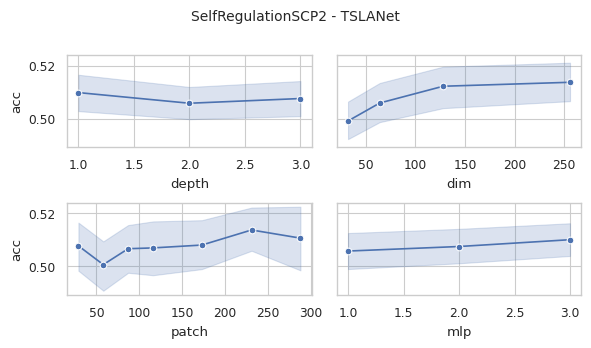

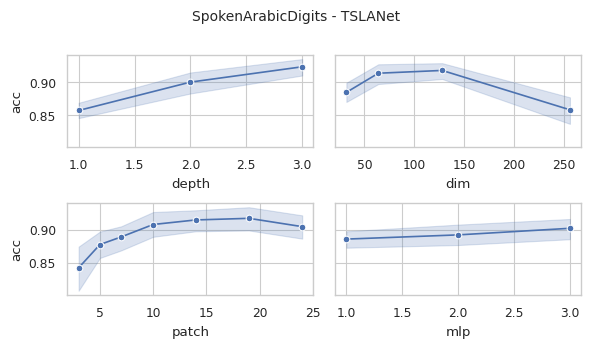

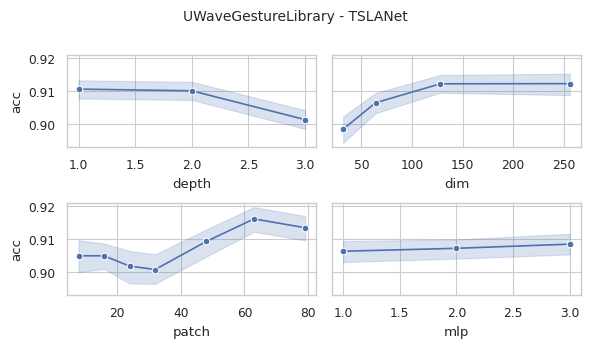

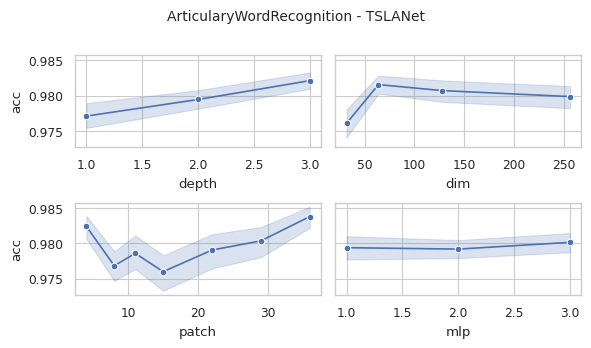

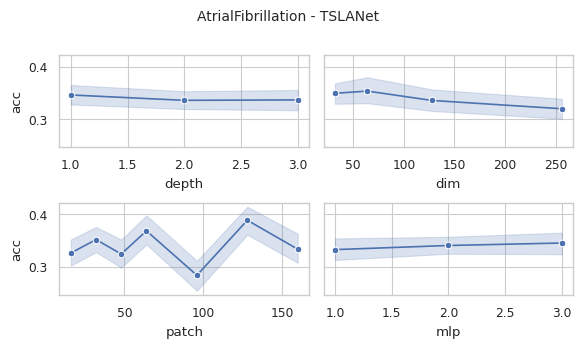

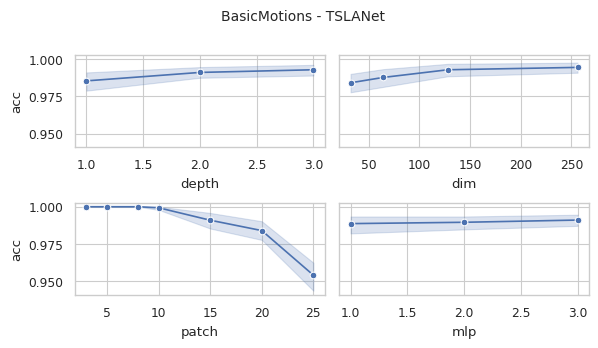

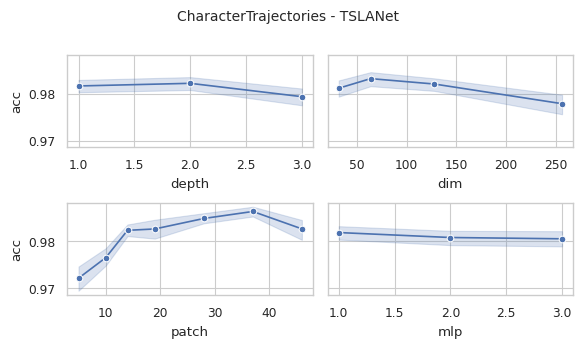

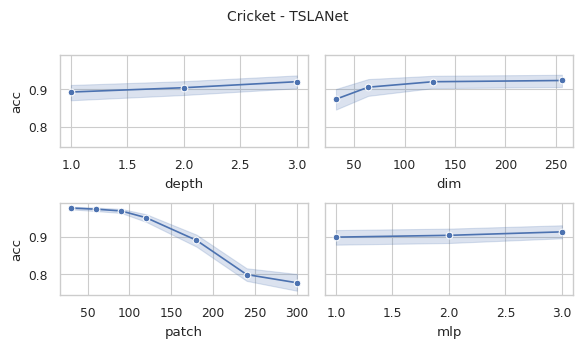

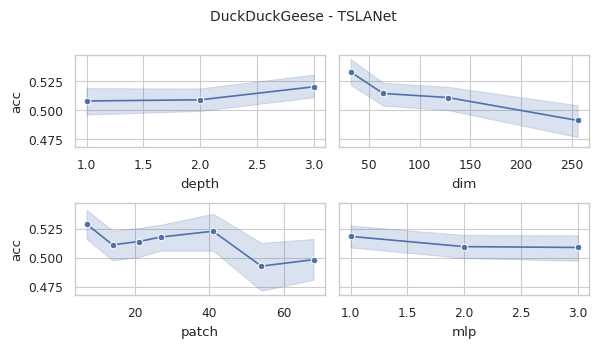

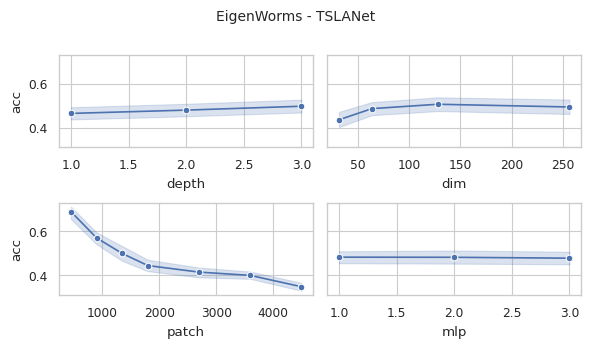

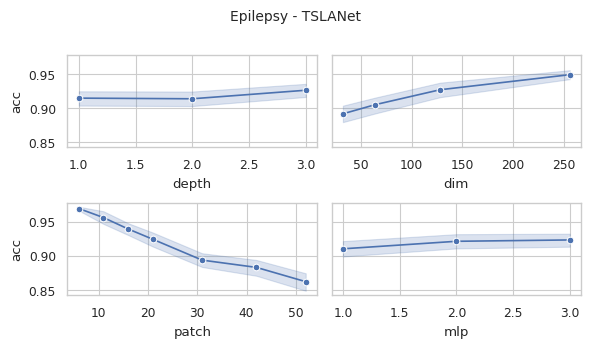

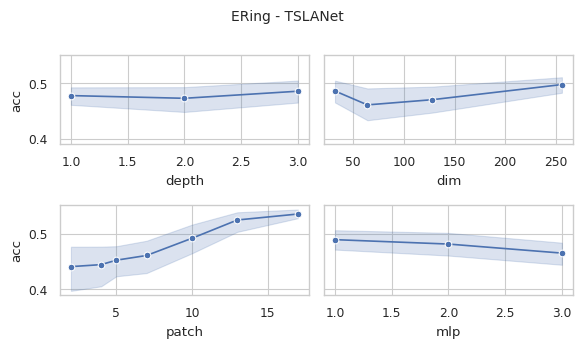

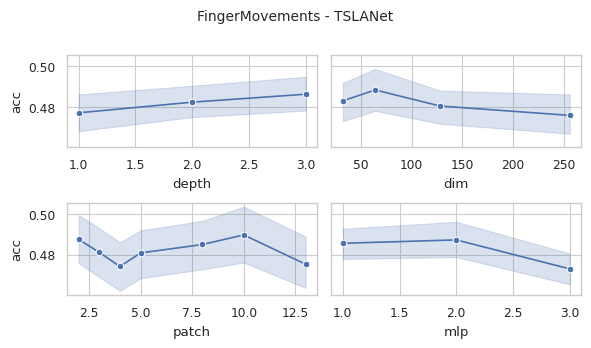

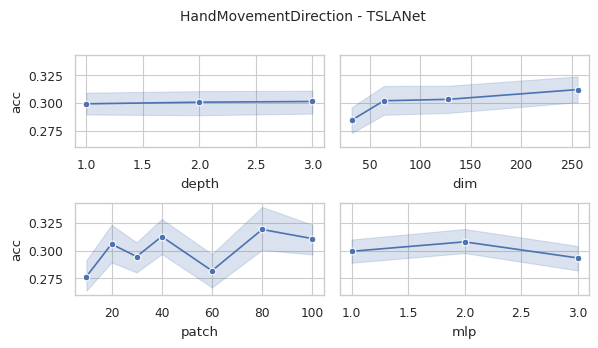

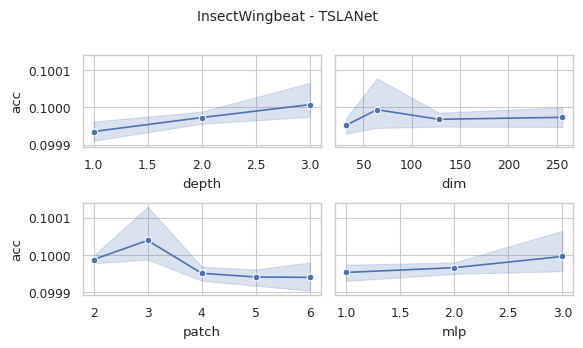

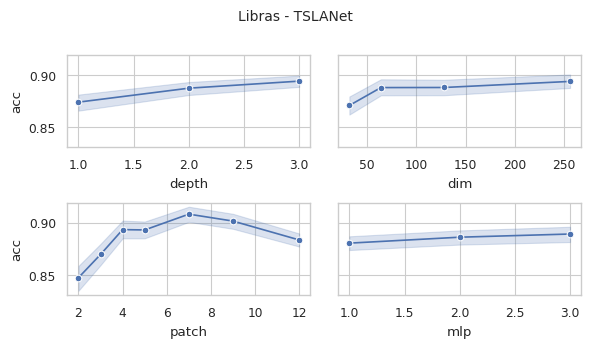

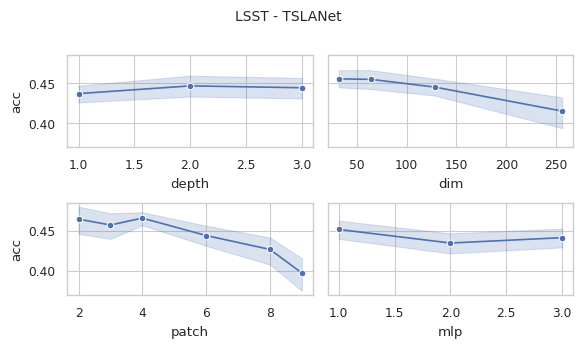

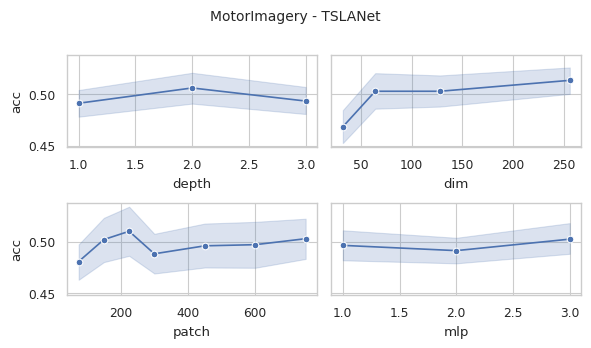

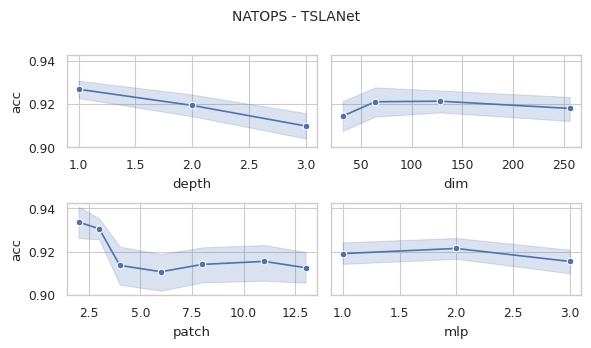

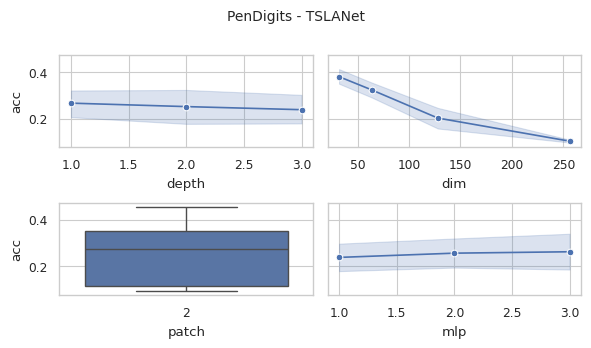

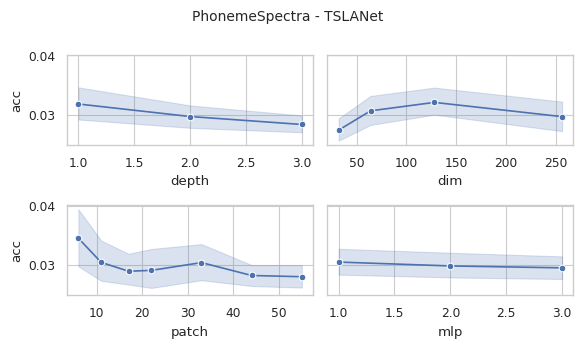

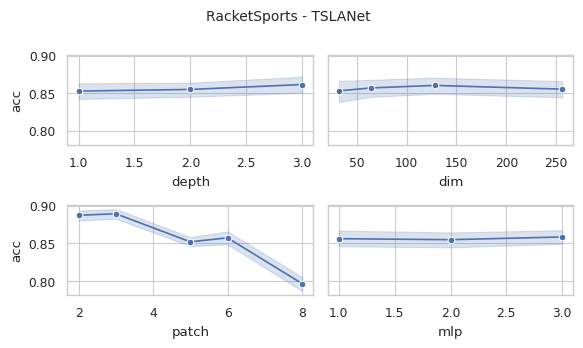

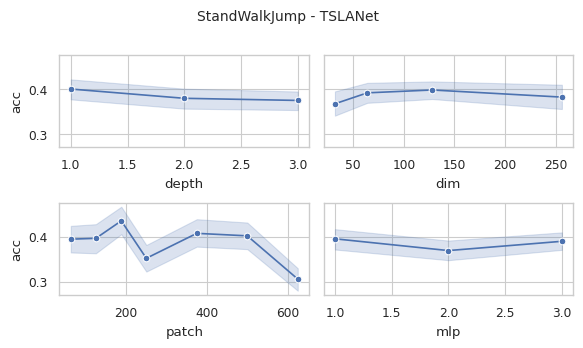

In [ ]:
model = 'TSLANet'
model_exp = 'TSLANet (no patience & 8:2 split)'
result_dict = dict()

for data_name in UEA_MTSC30:
    
    if os.path.exists(f'../03-full_results/{model_exp}/textFiles/CLS_{data_name}.txt'):
        with open(f'../03-full_results/{model_exp}/textFiles/CLS_{data_name}.txt', 'r') as file:
            data = file.read().splitlines()
    else:
        print('no file')
        continue

    result_lst = list()
    for i in range(len(data)):
        if data[i].startswith(data_name):
            data_meta = list(filter(lambda x: x != '', data[i].strip().split('_')))
            data_meta[1] = int(data_meta[1].replace('dim', ''))
            data_meta[2] = int(data_meta[2].replace('depth', ''))
            data_meta[3] = float(data_meta[3].replace('mask', ''))
            data_meta[4] = int(data_meta[4].replace('patch', ''))
            data_meta[5] = float(data_meta[5].replace('mlp', ''))
            data_meta[7] = (data_meta[7] == 'True')
            data_meta[9] = (data_meta[9] == 'True')
            data_meta[11] = (data_meta[11] == 'True')
            data_meta[13] = (data_meta[13] == 'True')

            acc = eval(data[i+2].split('acc:')[1].split(', mf1:')[0])

            ckpt_path = glob.glob('/data/yoom618/TSLib/logs (TSLANet)/{}/epoch=*.ckpt'.format(data[i].strip()))
            if len(ckpt_path) == 0:
                print('no ckpt')
                continue
            else:
                ckpt_path = ckpt_path[0]
            
            result_data = {
                'data_name': data_meta[0],
                'dim': data_meta[1],
                'depth': data_meta[2],
                'mask': data_meta[3],
                'patch': data_meta[4],
                'mlp': data_meta[5],
                'ASB': data_meta[7],
                'AF': data_meta[9],
                'ICB': data_meta[11],
                'preTr': data_meta[13],
                'acc': acc['test'],
                'acc_val': acc['val'],
                'model_size (KB)': os.path.getsize(ckpt_path) / 1024,
                'log_path': data[i].strip(),
            }

            result_lst.append(result_data)

    result_df = pd.DataFrame(result_lst)
    os.makedirs(f'./{model_exp}', exist_ok=True)
    result_df.to_csv(f'./{model_exp}/{data_name}.csv', index=False)
    result_dict[data_name] = result_df.copy()

    cols = ['depth', 'dim', 'patch', 'mlp']
    num_cols, num_rows = 2, 2
    
    # # Boxplot
    # sns.set_theme(style="whitegrid")
    # sns.set_context("paper", font_scale=1)
    # fig, axs = plt.subplots(ncols=num_cols, nrows=num_rows, figsize=(6, 3.5), sharey=True)
    # for i, col in enumerate(cols):
    #     sns.boxplot(x=col, y='acc', data=result_df, ax=axs[i%num_cols], legend=False)
    # fig.suptitle(f'{data_name} - {model}', fontsize=10)
    # plt.tight_layout()
    # plt.subplots_adjust(top=0.85)
    # display(fig)
    # plt.close(fig)

    # Lineplot
    sns.set_theme(style="whitegrid")
    sns.set_context("paper", font_scale=1)
    fig, axs = plt.subplots(ncols=num_cols, nrows=num_rows, figsize=(6, 3.5), sharey=True)
    for i, col in enumerate(cols):
        if result_df[col].unique().size == 1: 
            sns.boxplot(x=col, y='acc', data=result_df, ax=axs[i//num_cols][i%num_cols], legend=False)
        else:
            sns.lineplot(x=col, y='acc', data=result_df, ax=axs[i//num_cols][i%num_cols], legend=False, style='data_name', markers=True)
    fig.suptitle(f'{data_name} - {model}', fontsize=10)
    plt.tight_layout()
    plt.subplots_adjust(top=0.85)
    display(fig)
    plt.savefig(f'./{model_exp}/{data_name}.png', dpi=300, bbox_inches='tight')
    plt.close(fig)
    

    # # Lineplot where each line represents same hyperparameter combination except one
    # fig, axs = plt.subplots(ncols=num_cols, nrows=num_rows, figsize=(6, 3.5), sharey=True)
    # for i, col in enumerate(cols):
    #     col_rest = [c for c in cols if c != col]
    #     tmp_result = result_df.pivot_table(index=col_rest, columns=col, values='acc')
    #     tmp_result = pd.DataFrame(tmp_result.values, columns=tmp_result.columns)
    #     max_idx = tmp_result.mean(axis=1).idxmax()
    #     axs[i%num_cols].plot(tmp_result.T, marker='.', color='#111', alpha=0.2)
    #     axs[i%num_cols].plot(tmp_result.iloc[max_idx].T, marker='o', color='red', alpha=0.5)
    #     axs[i%num_cols].grid(False)
    #     axs[i%num_cols].set_xlabel(col)
    # fig.suptitle(f'{data_name} - {model}', fontsize=10)
    # plt.tight_layout()
    # plt.subplots_adjust(top=0.85)
    # display(fig)
    # plt.close(fig)
    
    
    

In [10]:
model_configs = {
    "depth" : [1, 2, 3],
    "emb_dim" : [32, 64, 128, 256],
    "mlp_ratio" : [1, 2, 3],
    "patch_size_ratio" : [2.5, 5, 7.5, 10, 15, 20, 25],
}


hyperparameter_combinations = make_combination(model_configs)

acc_all_df = pd.DataFrame(index=UEA_MTSC30, 
                          columns=[str(hp_comb) for hp_comb in hyperparameter_combinations])
for data_name in UEA_MTSC30:
    acc_data_dict = dict()
    for hyperparameter_combination in hyperparameter_combinations:
        seq_len = data_info[f'CLS_{data_name}']["seq_len"]
        enc_in = data_info[f'CLS_{data_name}']["enc_in"]
        depth = hyperparameter_combination['depth']
        emb_dim = hyperparameter_combination['emb_dim']
        mlp_ratio = hyperparameter_combination['mlp_ratio']
        patch_ratio = hyperparameter_combination['patch_size_ratio']
        patch_size = max(2, math.ceil((patch_ratio/100) * seq_len))
        
        if result_dict.get(data_name) is None:
            continue

        tmp = result_dict[data_name]
        try:
            acc = tmp[
                (tmp['depth'] == depth) &
                (tmp['dim'] == emb_dim) &
                (tmp['patch'] == patch_size) &
                (tmp['mlp'] == mlp_ratio)
            ]['acc'].values[0]
        except:
            acc = None
            print(f'no acc for {data_name} with {hyperparameter_combination}')
        acc_data_dict[str(hyperparameter_combination)] = acc

    acc_all_df.loc[data_name] = pd.Series(acc_data_dict)

In [11]:
acc_all_df.loc[:,'max'] = acc_all_df.max(axis=1)
acc_all_df.loc['avg'] = acc_all_df.mean(axis=0)
acc_all_df.sort_values(by='avg', ascending=False, inplace=True, axis=1)
acc_all_df

,max,"{'depth': 2, 'emb_dim': 32, 'mlp_ratio': 3, 'patch_size_ratio': 2.5}","{'depth': 3, 'emb_dim': 256, 'mlp_ratio': 1, 'patch_size_ratio': 2.5}","{'depth': 3, 'emb_dim': 64, 'mlp_ratio': 2, 'patch_size_ratio': 2.5}","{'depth': 3, 'emb_dim': 64, 'mlp_ratio': 2, 'patch_size_ratio': 5}","{'depth': 3, 'emb_dim': 64, 'mlp_ratio': 1, 'patch_size_ratio': 2.5}","{'depth': 2, 'emb_dim': 128, 'mlp_ratio': 3, 'patch_size_ratio': 2.5}","{'depth': 1, 'emb_dim': 32, 'mlp_ratio': 2, 'patch_size_ratio': 2.5}","{'depth': 1, 'emb_dim': 64, 'mlp_ratio': 1, 'patch_size_ratio': 2.5}","{'depth': 2, 'emb_dim': 128, 'mlp_ratio': 2, 'patch_size_ratio': 2.5}",...,"{'depth': 3, 'emb_dim': 256, 'mlp_ratio': 1, 'patch_size_ratio': 25}","{'depth': 1, 'emb_dim': 256, 'mlp_ratio': 3, 'patch_size_ratio': 25}","{'depth': 2, 'emb_dim': 256, 'mlp_ratio': 3, 'patch_size_ratio': 25}","{'depth': 2, 'emb_dim': 32, 'mlp_ratio': 2, 'patch_size_ratio': 25}","{'depth': 3, 'emb_dim': 256, 'mlp_ratio': 3, 'patch_size_ratio': 25}","{'depth': 2, 'emb_dim': 32, 'mlp_ratio': 1, 'patch_size_ratio': 25}","{'depth': 1, 'emb_dim': 32, 'mlp_ratio': 3, 'patch_size_ratio': 25}","{'depth': 1, 'emb_dim': 32, 'mlp_ratio': 2, 'patch_size_ratio': 20}","{'depth': 1, 'emb_dim': 256, 'mlp_ratio': 2, 'patch_size_ratio': 25}","{'depth': 1, 'emb_dim': 32, 'mlp_ratio': 1, 'patch_size_ratio': 25}"
EthanolConcentration,0.315589,0.235741,0.247148,0.315589,0.258555,0.281369,0.247148,0.247148,0.235741,0.254753,...,0.258555,0.285171,0.247148,0.269962,0.243346,0.224335,0.258555,0.235741,0.247148,0.254753
FaceDetection,0.540011,0.499432,0.5,0.500284,0.5,0.499432,0.500284,0.509364,0.499149,0.499716,...,0.499149,0.501703,0.505675,0.500851,0.5,0.501703,0.499149,0.498297,0.499432,0.517026
Handwriting,0.568235,0.355294,0.568235,0.403529,0.452941,0.434118,0.475294,0.332941,0.376471,0.485882,...,0.292941,0.28,0.257647,0.094118,0.242353,0.064706,0.090588,0.181176,0.227059,0.201176
Heartbeat,0.795122,0.77561,0.765854,0.746341,0.770732,0.770732,0.746341,0.721951,0.741463,0.785366,...,0.726829,0.760976,0.721951,0.717073,0.746341,0.75122,0.736585,0.726829,0.746341,0.741463
JapaneseVowels,0.989189,0.975676,0.967568,0.972973,0.972973,0.978378,0.972973,0.97027,0.975676,0.972973,...,0.975676,0.983784,0.967568,0.981081,0.967568,0.983784,0.972973,0.983784,0.981081,0.975676
PEMS-SF,0.797688,0.635838,0.797688,0.739884,0.66474,0.578035,0.768786,0.745665,0.768786,0.710983,...,0.578035,0.641618,0.624277,0.693642,0.624277,0.745665,0.630058,0.641618,0.647399,0.699422
SelfRegulationSCP1,0.856655,0.720137,0.750853,0.733788,0.740614,0.761092,0.8157,0.771331,0.764505,0.8157,...,0.675768,0.668942,0.791809,0.788396,0.750853,0.78157,0.668942,0.767918,0.549488,0.648464
SelfRegulationSCP2,0.572222,0.494444,0.555556,0.511111,0.5,0.533333,0.522222,0.5,0.5,0.511111,...,0.433333,0.505556,0.472222,0.5,0.522222,0.494444,0.444444,0.5,0.55,0.538889
SpokenArabicDigits,0.982265,0.964984,0.829468,0.952706,0.914052,0.950432,0.876307,0.792633,0.819009,0.864939,...,0.950887,0.893588,0.933606,0.858572,0.884038,0.769441,0.823556,0.828104,0.892678,0.759436
UWaveGestureLibrary,0.934375,0.9,0.921875,0.89375,0.89375,0.903125,0.928125,0.878125,0.89375,0.915625,...,0.915625,0.9,0.93125,0.89375,0.896875,0.91875,0.921875,0.915625,0.909375,0.915625


In [ ]:
pd.set_option("display.precision", 14)
acc_all_df.iloc[:,[0,1]]*100

,max,"{'depth': 2, 'emb_dim': 32, 'mlp_ratio': 3, 'patch_size_ratio': 2.5}"
EthanolConcentration,31.5589368343353,23.5741451382637
FaceDetection,54.0011346340179,49.9432474374771
Handwriting,56.8235278129578,35.5294108390808
Heartbeat,79.5121967792511,77.5609731674194
JapaneseVowels,98.9189207553864,97.5675702095032
PEMS-SF,79.7687888145447,63.5838150978088
SelfRegulationSCP1,85.6655299663544,72.0136523246765
SelfRegulationSCP2,57.2222232818604,49.444442987442
SpokenArabicDigits,98.2264637947083,96.4984059333801
UWaveGestureLibrary,93.4374988079071,89.9999976158142


## move ckpt

In [9]:
import shutil
for data_name in result_dict.keys():
    log_dirs = result_dict[data_name][result_dict[data_name]['acc'] == result_dict[data_name]['acc'].max()]['log_path'].values
    
    for log_dir in log_dirs:
        log_dir = f'/data/yoom618/TSLib/logs (TSLANet)/{log_dir}'
        if os.path.exists(log_dir):
            print(f'move {log_dir} to {log_dir.replace("logs (TSLANet)", "checkpoints_best/TSLANet")}')
            os.makedirs(log_dir.replace("logs (TSLANet)", "checkpoints_best/TSLANet"), exist_ok=True)
            shutil.move(log_dir, log_dir.replace("logs (TSLANet)", "checkpoints_best/TSLANet"))
        else:
            print(f'{log_dir} not exists')


move /data/yoom618/TSLib/logs (TSLANet)/EthanolConcentration_dim64_depth3_mask0.4_patch44_mlp2.0___ASB_True__AF_True__ICB_True__preTr_True_06_32_27 to /data/yoom618/TSLib/checkpoints_best/TSLANet/EthanolConcentration_dim64_depth3_mask0.4_patch44_mlp2.0___ASB_True__AF_True__ICB_True__preTr_True_06_32_27
move /data/yoom618/TSLib/logs (TSLANet)/EthanolConcentration_dim256_depth1_mask0.4_patch351_mlp1.0___ASB_True__AF_True__ICB_True__preTr_True_11_11_18 to /data/yoom618/TSLib/checkpoints_best/TSLANet/EthanolConcentration_dim256_depth1_mask0.4_patch351_mlp1.0___ASB_True__AF_True__ICB_True__preTr_True_11_11_18
move /data/yoom618/TSLib/logs (TSLANet)/FaceDetection_dim32_depth1_mask0.4_patch16_mlp2.0___ASB_True__AF_True__ICB_True__preTr_True_01_35_56 to /data/yoom618/TSLib/checkpoints_best/TSLANet/FaceDetection_dim32_depth1_mask0.4_patch16_mlp2.0___ASB_True__AF_True__ICB_True__preTr_True_01_35_56
move /data/yoom618/TSLib/logs (TSLANet)/Handwriting_dim256_depth3_mask0.4_patch4_mlp1.0___ASB_True